# Introduction

* Reading long articles can be time-consuming and inefficient.

* Text Summarization helps in **automatically condensing large text documents**
while preserving the most important information.

* In this notebook, we build a **fully explainable extractive text summarizer**
and visualize **how and why** sentences are selected using intuitive NLP plots.


## Problem Statement

Given a long text document:

- 🧠 Identify important words  
- ⭐ Score sentences based on importance  
- ✂️ Generate a concise summary  
- 📊 Visually explain the summarization process  

The goal is not just to summarize, but to **make the summarization transparent**.


## Approach Overview

The summarization pipeline follows these steps:

**1️. Text preprocessing (cleaning & tokenization)**

**2️. Word frequency analysis**  

**3️. Sentence importance scoring**

**4️. Top-sentence selection**  

**5️. Visual interpretation of results**

# This is a **pure NLP-based extractive summarization** approach.


# But the question is : Why Extractive Summarization?

✔ Preserves original meaning  
✔ Easy to interpret  
✔ No hallucinations  
✔ Suitable for news & articles  

This makes it ideal for **educational and analytical use-cases**.


# Importing the required modules

In [1]:
import nltk
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

# Storing the text for Summarization

In [2]:
text = """
Natural Language Processing (NLP) is a subfield of artificial intelligence that focuses on the interaction between computers and human language. It aims to enable machines to read, understand, interpret, and generate human language in a meaningful way. NLP combines concepts from computer science, linguistics, and machine learning to process and analyze large amounts of textual data.

The history of Natural Language Processing dates back to the 1950s, when early researchers attempted to build rule-based systems for language translation. One of the earliest applications was machine translation, where computers were used to translate text from one language to another. However, these early systems were limited due to the complexity and ambiguity of natural language.

With the growth of computational power and the availability of large datasets, NLP has shifted from rule-based approaches to statistical and machine learning-based methods. Techniques such as tokenization, stemming, part-of-speech tagging, and named entity recognition became fundamental components of modern NLP systems. These techniques help computers identify the structure and meaning of text.

In recent years, deep learning has significantly advanced the field of NLP. Neural networks, particularly transformer-based architectures, have enabled machines to understand context and semantics more effectively. Models such as recurrent neural networks and attention-based systems have improved tasks like language translation, text summarization, and question answering.

Natural Language Processing is widely used in real-world applications. Search engines rely on NLP to understand user queries and retrieve relevant information. Chatbots and virtual assistants use NLP to communicate with users in a natural and conversational manner. Sentiment analysis systems analyze opinions and emotions expressed in text, which is useful for social media monitoring and customer feedback analysis.

Text summarization is another important application of NLP. It involves automatically generating a concise summary of a longer document while preserving its key information. Summarization techniques can be broadly classified into extractive and abstractive methods. Extractive summarization selects important sentences directly from the original text, whereas abstractive summarization generates new sentences that capture the overall meaning.

Despite significant progress, NLP still faces challenges such as handling ambiguity, understanding context, and dealing with low-resource languages. Research in this field continues to evolve, with a focus on improving accuracy, fairness, and explainability. As language remains a core component of human communication, NLP is expected to play an increasingly important role in the development of intelligent systems.

"""


# Cleaning and normalizing the text by removing noise and stopwords to retain only meaningful words


In [3]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]
    return words

# Tokenizing the text into sentences

In [4]:
sentences = sent_tokenize(text)

# Computing normalized word frequencies to measure the importance of each word in the document

In [5]:
word_frequencies = {}

for word in clean_text(text):
    if word not in word_frequencies:
        word_frequencies[word] = 1
    else:
        word_frequencies[word] += 1

max_freq = max(word_frequencies.values())

for word in word_frequencies:
    word_frequencies[word] /= max_freq


# Scoring each sentence by summing the importance of the words it contains


In [6]:
sentence_scores = {}

for sent in sentences:
    for word in word_tokenize(sent.lower()):
        if word in word_frequencies:
            if sent not in sentence_scores:
                sentence_scores[sent] = word_frequencies[word]
            else:
                sentence_scores[sent] += word_frequencies[word]


# Selecting the top-scoring sentences and combining them to generate the final summary

In [7]:
summary_length = int(len(sentences) * 0.4)  # 40% summary
summary_sentences = sorted(sentence_scores, key=sentence_scores.get, reverse=True)[:summary_length]

summary = " ".join(summary_sentences)
print(summary)


Natural Language Processing (NLP) is a subfield of artificial intelligence that focuses on the interaction between computers and human language. The history of Natural Language Processing dates back to the 1950s, when early researchers attempted to build rule-based systems for language translation. As language remains a core component of human communication, NLP is expected to play an increasingly important role in the development of intelligent systems. Models such as recurrent neural networks and attention-based systems have improved tasks like language translation, text summarization, and question answering. Extractive summarization selects important sentences directly from the original text, whereas abstractive summarization generates new sentences that capture the overall meaning. One of the earliest applications was machine translation, where computers were used to translate text from one language to another. However, these early systems were limited due to the complexity and am

# Visualizing the most frequent and influential words present in the original document

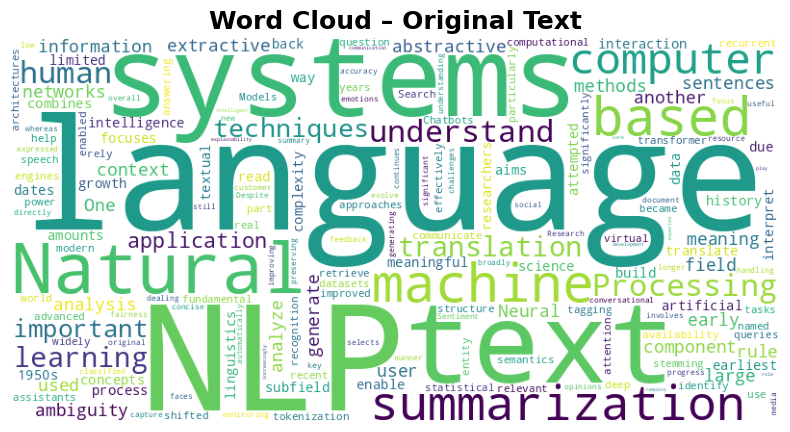

In [8]:
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud – Original Text",fontweight='bold',fontsize=18)
plt.show()

# Visualizing the key terms retained in the generated summary

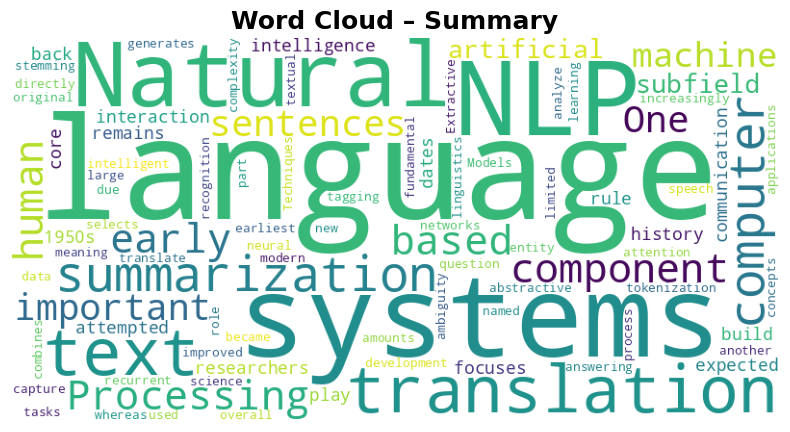

In [9]:
wc_summary = WordCloud(width=800, height=400, background_color='white')
wc_summary.generate(summary)

plt.figure(figsize=(10,5))
plt.imshow(wc_summary)
plt.axis("off")
plt.title("Word Cloud – Summary",fontweight='bold',fontsize=18)
plt.show()


# Visualizing the importance score of each sentence to understand how the summary is formed

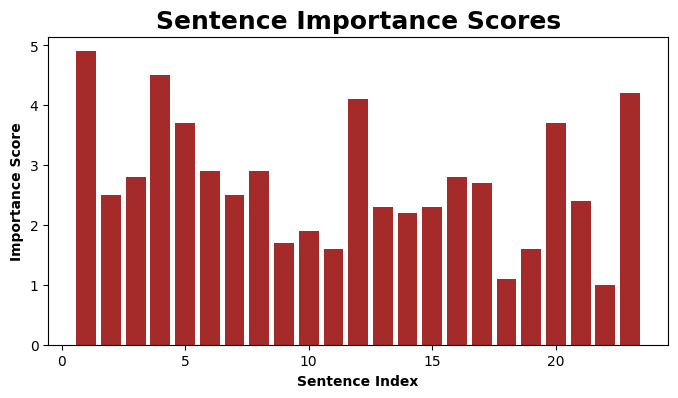

In [10]:
scores = list(sentence_scores.values())
sent_ids = range(1, len(scores)+1)

plt.figure(figsize=(8,4))
plt.bar(sent_ids, scores,color='brown')
plt.xlabel("Sentence Index",fontweight='bold')
plt.ylabel("Importance Score",fontweight='bold')
plt.title("Sentence Importance Scores",fontweight='bold',fontsize=18)
plt.show()

# Comparing the word count of the original text and the generated summary to visualize compression

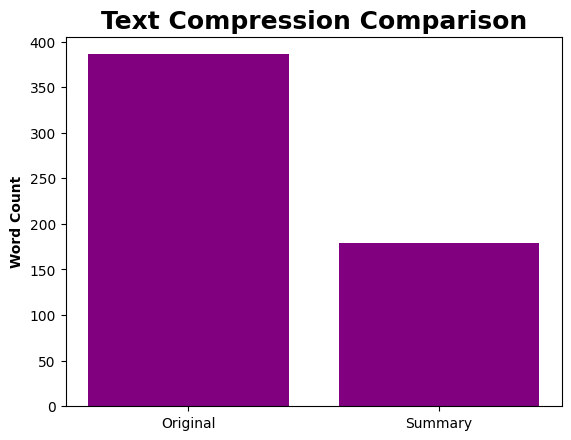

In [11]:
labels = ["Original", "Summary"]
lengths = [len(text.split()), len(summary.split())]

plt.bar(labels, lengths,color='purple')
plt.title("Text Compression Comparison",fontweight='bold',fontsize=18)
plt.ylabel("Word Count",fontweight='bold')
plt.show()

# Visualizing which sentences were selected or ignored across the original document order

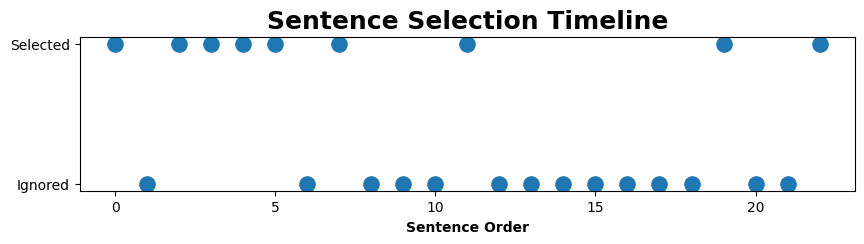

In [12]:
selected = [1 if s in summary_sentences else 0 for s in sentences]

plt.figure(figsize=(10,2))
plt.scatter(range(len(sentences)), selected, s=120)
plt.yticks([0,1], ["Ignored", "Selected"])
plt.xlabel("Sentence Order",fontweight='bold')
plt.title("Sentence Selection Timeline",fontweight='bold',fontsize=18)
plt.show()

# Measuring how many important keywords from the original text are preserved in the summary

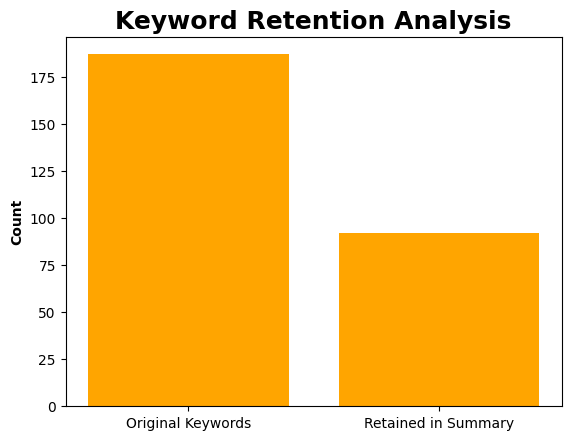

In [13]:
orig_words = set(clean_text(text))
sum_words = set(clean_text(summary))

retained = orig_words.intersection(sum_words)

sizes = [len(orig_words), len(retained)]
labels = ["Original Keywords", "Retained in Summary"]

plt.bar(labels, sizes,color='orange')
plt.title("Keyword Retention Analysis",fontweight='bold',fontsize=18)
plt.ylabel("Count",fontweight='bold',)
plt.show()

# Identifying the most influential keywords using TF-IDF scores to understand what drives the summary

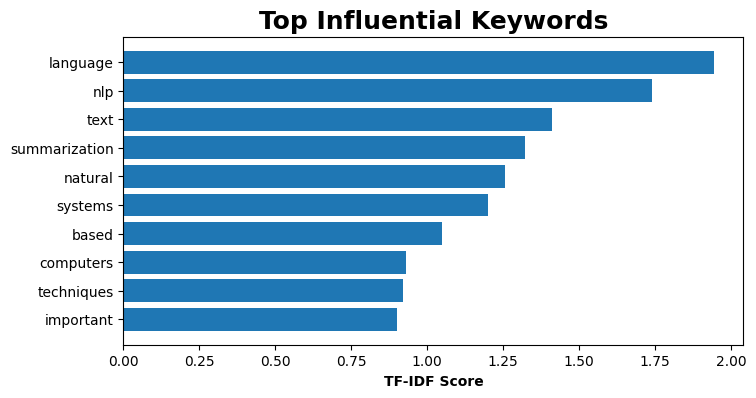

In [14]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(sentences)

tfidf_scores = X.sum(axis=0).A1
terms = vectorizer.get_feature_names_out()

top_indices = tfidf_scores.argsort()[-10:][::-1]

plt.figure(figsize=(8,4))
plt.barh([terms[i] for i in top_indices], tfidf_scores[top_indices])
plt.xlabel("TF-IDF Score",fontweight='bold')
plt.title("Top Influential Keywords",fontweight='bold',fontsize=18)
plt.gca().invert_yaxis()
plt.show()

# Visualizing the proportion of original content retained versus removed in the summary

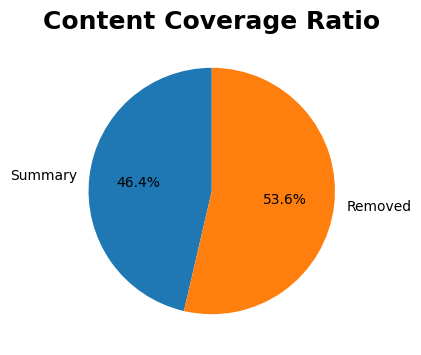

In [15]:
coverage = round(len(summary.split()) / len(text.split()) * 100, 2)

plt.figure(figsize=(4,4))
plt.pie([coverage, 100-coverage],
        labels=["Summary", "Removed"],
        autopct="%1.1f%%",
        startangle=90)
plt.title("Content Coverage Ratio",fontweight='bold',fontsize=18)
plt.show()

# Comparing vocabulary diversity between the original text and the generated summary

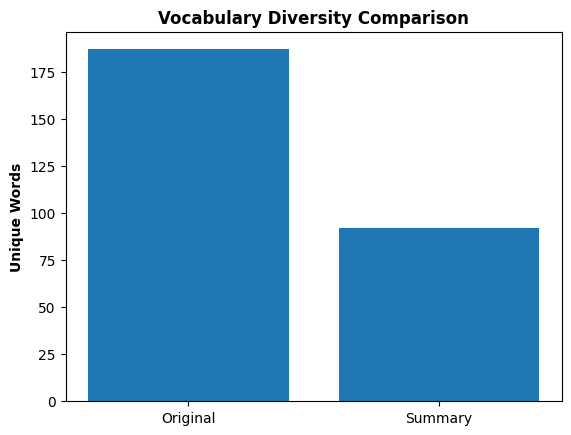

In [16]:
labels = ["Original", "Summary"]
vocab_sizes = [len(set(clean_text(text))), len(set(clean_text(summary)))]

plt.bar(labels, vocab_sizes)
plt.title("Vocabulary Diversity Comparison",fontweight='bold')
plt.ylabel("Unique Words",fontweight='bold')
plt.show()

## Results Summary

* Successfully reduced text length while preserving meaning  
* Key terms retained in the summary  
* Redundant sentences removed  
* Clear interpretability through visual analytics  

The summary captures the **core idea of the original document**.

## Key Takeaways

-  NLP can summarize text without deep learning  
-  Sentence scoring is effective for extractive summarization  
-  Visualization improves trust & understanding  
-  Explainability is as important as accuracy  


## Limitations

- Extractive summaries may lack smooth flow  
- No semantic paraphrasing  
- Performance depends on word frequency  

These can be improved using **transformer-based models**.

# Thank You :)